In [145]:
# 1
import pandas as pd
import numpy as np

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

print(df.head(n=10))

numeric_data = df.select_dtypes(include=[np.number])
categorical_data = df.select_dtypes(exclude=[np.number])

print("\nNumeric Data: ")
print(numeric_data.columns)

print("\nCategorical Data: ")
print(categorical_data.columns)

    age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0  14.0     NaN                       7.9      Instagram          7.4   
1  19.0  female                       1.9         TikTok          8.0   
2  17.0  female                       1.3      Instagram          7.6   
3  15.0    male                       7.4         TikTok          6.9   
4  15.0  female                       NaN           Both          4.9   
5   NaN  female                       7.4           Both          4.4   
6  18.0  female                       2.5      Instagram          6.4   
7  16.0    male                       4.0           Both          4.2   
8  19.0  female                       3.3         TikTok          5.0   
9  15.0    male                       1.9         TikTok          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22   

In [146]:
# 2
print(df.describe())

# With a Standard Deviation of 2.89, Stress Level shows the highest variance among the variables

               age  daily_social_media_hours  sleep_hours  \
count  1105.000000               1056.000000  1008.000000   
mean     15.901357                  4.544129     6.443155   
std       2.016294                  2.027443     1.457104   
min      13.000000                  1.000000     4.000000   
25%      14.000000                  2.800000     5.100000   
50%      16.000000                  4.500000     6.400000   
75%      18.000000                  6.300000     7.700000   
max      19.000000                  8.000000     9.000000   

       screen_time_before_sleep  academic_performance  physical_activity  \
count               1140.000000           1080.000000        1092.000000   
mean                   1.735965              2.986148           1.016392   
std                    0.717721              0.578481           0.581912   
min                    0.500000              2.000000           0.000000   
25%                    1.100000              2.490000           0.5000

In [40]:
# 2b
mean_of_social = df["daily_social_media_hours"].mean()
print("\nMean of Social Media Hours: ")
print(mean_of_social)

print("\nMean of Sleep Hours: ")
mean_of_sleep = df["sleep_hours"].mean()
print(mean_of_sleep)

print("\nMedian of Social Media Hours: ")
median_of_social = df["daily_social_media_hours"].median()
print(median_of_social)

print("\nMedian of Sleep Hours: ")
median_of_sleep = df["sleep_hours"].median()
print(median_of_sleep)

print("\nSince the mean and the median values are quite similar in range, this is a Normal distribution.")


Mean of Social Media Hours: 
4.544128787878788

Mean of Sleep Hours: 
6.443154761904762

Median of Social Media Hours: 
4.5

Median of Sleep Hours: 
6.4

Since the mean and the median values are quite similar in range, this is a Normal distribution.


In [147]:
# 3a
print([x for x in df.columns if df[x].isnull().any()])

# 3b
print("\nCalculating percentage of missing values in Social Media Hours: ")
print((df["daily_social_media_hours"].isnull().sum() / len(df)) * 100)

print("\nCalculating percentage of missing values in Sleep Hours: ")
print((df["sleep_hours"].isnull().sum() / len(df)) * 100)

print("\nCalculating percentage of missing values in Screen Time Before Sleep: ")
print((df["screen_time_before_sleep"].isnull().sum() / len(df)) * 100)

print("\nSince all of the columns here are missing less than 30%, we just have to impute them with either mean of median values. I will use Median to avoid outlier skew")

['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']

Calculating percentage of missing values in Social Media Hours: 
12.0

Calculating percentage of missing values in Sleep Hours: 
16.0

Calculating percentage of missing values in Screen Time Before Sleep: 
5.0

Since all of the columns here are missing less than 30%, we just have to impute them with either mean of median values. I will use Median to avoid outlier skew


In [148]:
# 3c
print("\nCalculating percentage of missing values in Stress Level: ")
print((df["stress_level"].isnull().sum() / len(df)) * 100)

print("\nCalculating percentage of missing values in Anxiety Level: ")
print((df["anxiety_level"].isnull().sum() / len(df)) * 100)

print("\nCalculating percentage of missing values in Addiction Level: ")
print((df["addiction_level"].isnull().sum() / len(df)) * 100)

print("\nSince all of the columns here are missing less than 30% again, we just have to impute them with either mean of median values. I will use Median to avoid outlier skew")


Calculating percentage of missing values in Stress Level: 
9.0

Calculating percentage of missing values in Anxiety Level: 
9.0

Calculating percentage of missing values in Addiction Level: 
6.0

Since all of the columns here are missing less than 30% again, we just have to impute them with either mean of median values. I will use Median to avoid outlier skew


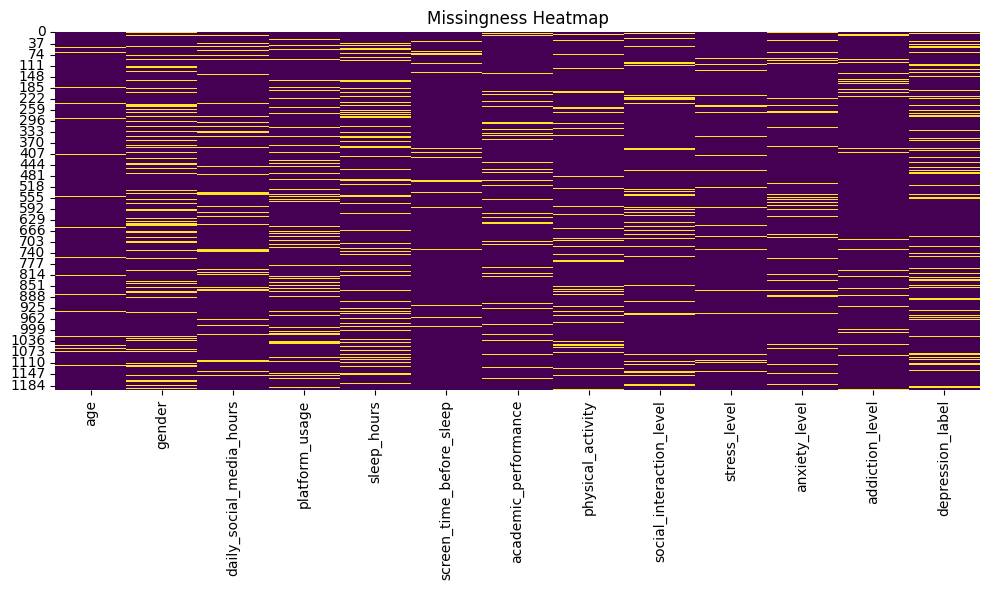

Here in the mental health indicators like Stress level, anxiety level, addiction level and depression level have data that are missing at random as we can see in the heatmap that there are no visible regular intervals between two consequtive missing values.


In [149]:
# 3d
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missingness Heatmap')

plt.tight_layout()
plt.show()

print("Here in the mental health indicators like Stress level, anxiety level, addiction level and depression level have data that are missing at random as we can see in the heatmap that there are no visible regular intervals between two consequtive missing values.")

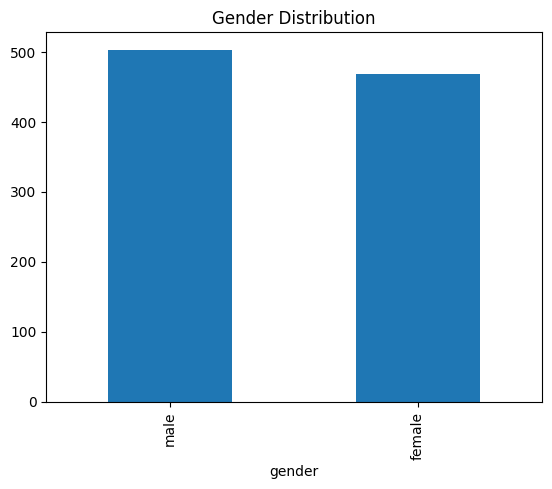

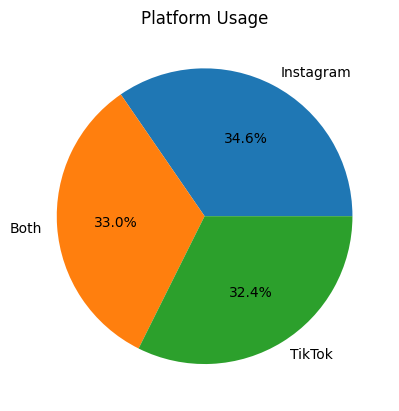

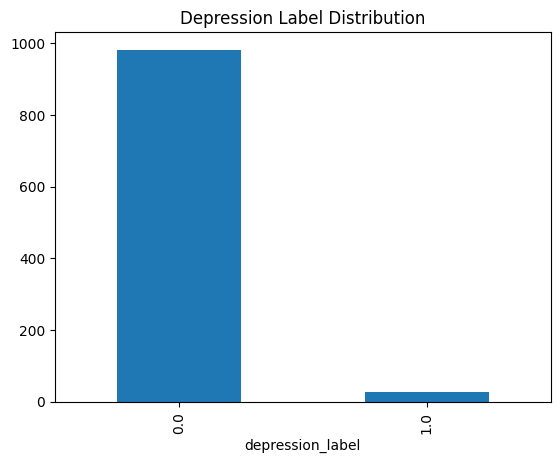

In [150]:
# 4.
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

sizes = df["platform_usage"].value_counts()
fig, ax = plt.subplots()
ax.pie(sizes, labels=sizes.index, autopct='%1.1f%%')
plt.title("Platform Usage")
plt.show()

df['depression_label'].value_counts().plot(kind='bar')
plt.title("Depression Label Distribution")
plt.show()

/tmp/ipykernel_18292/807778347.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["stress_level"].dropna(), df["anxiety_level"].dropna(), df["addiction_level"].dropna()], labels=["Stress Level", "Anxiety Level", "Addiction Level"])


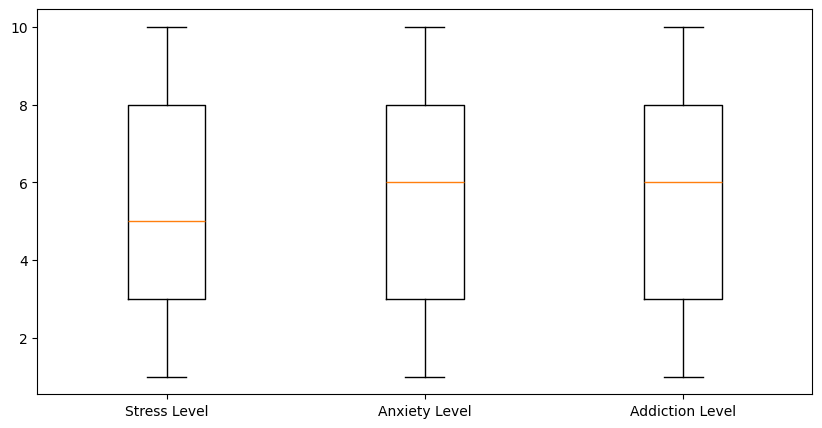

In [151]:
plt.figure(figsize=(10, 5))
plt.boxplot([df["stress_level"].dropna(), df["anxiety_level"].dropna(), df["addiction_level"].dropna()], labels=["Stress Level", "Anxiety Level", "Addiction Level"])
plt.show()

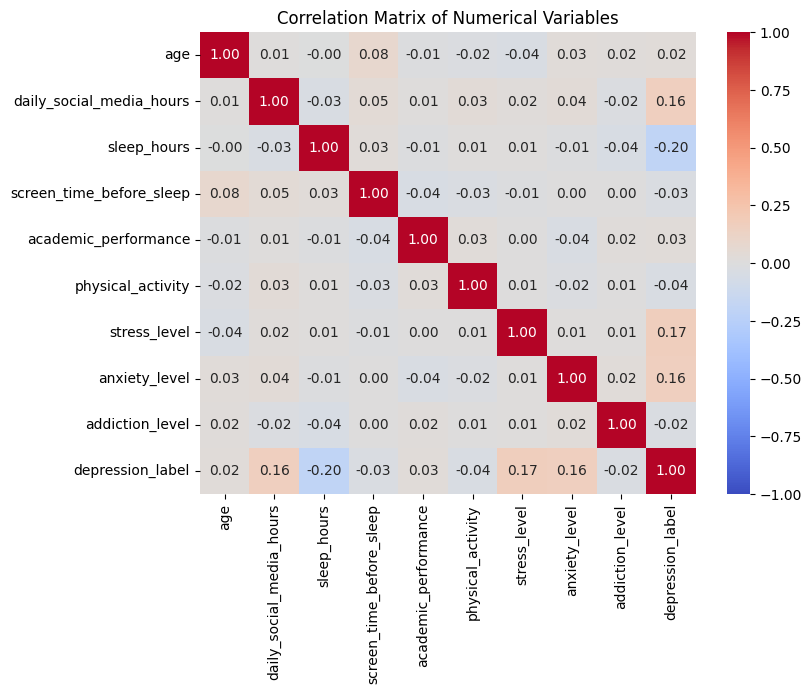

Without encoding, categorical variables are only subject to surface level analysis like frequency or mode as any numerical calculations cannot be performed on them. They have to converted into numerical values by either encoding or binning


In [120]:
# 5
plt.figure(figsize=(8, 6))
corr_matrix = df[[col for col in ['age', 'daily_social_media_hours', 'sleep_hours','screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label'] if col in df.columns]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

print("Without encoding, categorical variables are only subject to surface level analysis like frequency or mode as any numerical calculations cannot be performed on them. They have to converted into numerical values by either encoding or binning") 

In [152]:
# 6a
social_media_hours = df["daily_social_media_hours"].dropna()
sleep_hours = df["sleep_hours"].dropna()
stress_level = df["stress_level"].dropna()
anxiety_level = df["anxiety_level"].dropna()

q1_a = social_media_hours.quantile(0.25)
q3_a = social_media_hours.quantile(0.75)
IQR_social = q3_a - q1_a
MAX_social = q3_a + (IQR_social * 1.5)
MIN_social = q1_a - (IQR_social * 1.5)

q1_b = sleep_hours.quantile(0.25)
q3_b = sleep_hours.quantile(0.75)
IQR_sleep = q3_b - q1_b
MAX_sleep = q3_b + (IQR_sleep * 1.5)
MIN_sleep = q1_b - (IQR_sleep * 1.5)

q1_c = stress_level.quantile(0.25)
q3_c = stress_level.quantile(0.75)
IQR_stress = q3_c - q1_c
MAX_stress = q3_c + (IQR_stress * 1.5)
MIN_stress = q1_c - (IQR_stress * 1.5)

q1_d = anxiety_level.quantile(0.25)
q3_d = anxiety_level.quantile(0.75)
IQR_anxiety = q3_d - q1_d
MAX_anxiety = q3_d + (IQR_anxiety * 1.5)
MIN_anxiety = q1_d - (IQR_anxiety * 1.5)

print("Outliers in Daily_Social_Media_Hours")
social_outliers = ((social_media_hours > MAX_social) | (social_media_hours < MIN_social)).sum()
print(social_outliers)

print("Outliers in Sleep_Hours")
sleep_outliers = ((sleep_hours > MAX_sleep) | (sleep_hours < MIN_sleep)).sum()
print(sleep_outliers)

print("Outliers in Stress Level")
stress_outliers = ((stress_level > MAX_stress) | (stress_level < MIN_stress)).sum()
print(stress_outliers)

print("Outliers in Anxiety Level")
anxiety_outliers = ((anxiety_level > MAX_anxiety) | (anxiety_level < MIN_anxiety)).sum()
print(anxiety_outliers)

print("\nExtreme values in social media usage do not represent data errors sometimes. There might be few cases where people with jobs on social media like influencers, marketers, etc. may have a social media usage that is higher than average.")

Outliers in Daily_Social_Media_Hours
0
Outliers in Sleep_Hours
0
Outliers in Stress Level
0
Outliers in Anxiety Level
0

Extreme values in social media usage do not represent data errors sometimes. There might be few cases where people with jobs on social media like influencers, marketers, etc. may have a social media usage that is higher than average.


## 7 
Generally we see a pattern where higher social media usage patterns might affect sleep time and that in turn affects their mental health factors like anxiety and depression level. 